# Final Project Report


## 1. Introduction

### Background Information

The following 2 data sets, are a part of a research group named the **Pacific Laboratory for Artificial Intelligence (PLAI)** in the faculty of Computer Science at UBC, led **Frank Wood**. The premise of their research is to collect data on how people play video games and, most importantly, use that collected data and gameplay recordings to train their ever-evolving AI to play and think like us humans. The game in question is Minecraft, the 2nd highest-selling game of all time, with over 300 million sales across all platforms, according to game news publisher **GameSpot**. The research takes place in a virtual server named **"PLAICRAFT"**, named after their group name. Each participant can play from the comfort of their own home, as the server can be accessed virtually by anyone who participates in the project on their website (https://plaicraft.ai). The research officially started on February 22nd, 2024, with the publication of their formal invitation on YouTube (https://www.youtube.com/watch?v=PdIjQAhQ3Xk&t=79s).

### Figure Legend
- `Figures 1.0-1.5` represent a data table
- `Figures 2.0-2.2` represent a visualization

### Dataset Overview

`players.csv`:
- Number of observations: 196  
- Number of variables: 7  
- Unit of observation: One row per player  

`sessions.csv`:
- Number of observations: 1535 
- Number of variables: 5  
- Unit of observation: One row per game session  


### Variables Summary

| Dataset| Variable | Type | Description | Use in Analysis|
|---------|----------|----------|------------------|-------------------------------|
| players.csv | `experience` | Categorical | Player’s self-reported skill level | Explanatory variable |
| players.csv | `subscribe` | Logical | Whether the player subscribed to the newsletter | Not used for this analysis    |
| players.csv | `hashedEmail`| Character | Unique player ID | Used when merging datasets |
| players.csv | `played_hours` | Double | Total hours the player spent in-game | Response variable |
| players.csv | `name` | Character | Player’s name | Not used|
| players.csv | `gender`| Categorical  | Player’s gender | Explanatory variable|
| players.csv | `Age`| Integer| Player’s age in years | Explanatory variable|
| sessions.csv | `hashedEmail`| Character| Links each session to a player in players.csv | Used when merging datasets|
| sessions.csv | `start_time`| Datetime (Character)| Start time of the play session| Used for time analysis|
| sessions.csv | `end_time`| Datetime (Character)| End time of the play session | Used for time analysis|
| sessions.csv | `original_start_time` | Double| Original timestamp of session start | Not used|
| sessions.csv | `original_end_time`| Double| Original timestamp of session end | Not used|


*`Figure 1.0`, Variables summary of both player.csv & sessions.csv combined.*

### Issues and Potential Issues

- Some players appear multiple times in the `sessions.csv` dataset but only once in `players.csv`
- Some values for age were missing in `players.csv`
- The experience level pro has very few players, making averages less accurate 
- Experience level is self-reported, so players might not have rated themselves consistently
- Players might have been idle, making playtime less accurate


### Question

**Broad Question:**   
What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?

**Specific Question:**  
Can a player’s age, the total number of hours they have played in the Minecraft server and experience level predict if they are subscribed to the newsletter?

**Description:**  
This question explores which types are more likely to subscribe to the newsletter. We use only the `players.csv` dataset, which includes each player’s age, gender, experience level, and total hours played. The response variable is `subscribe`, representing whether a player is subscribed to the newsletter, and the explanatory variables are `Age`, `played_hours`, and `experience`.    

Before analysis, the dataset will be tidied by removing unnecessary columns and missing values, and converting character variables into factors for classification.


## 2. Methods & Results

### Summary Statistics for `players.csv`
Mean Value for Each Quantitative Variable:
| Variable | Mean |
|-----------|------|
| `played_hours` | 5.90 | 
| `Age` | 21.14 | 

*`Figure 1.1`, Summary mean value for "Played_hours" and "Age".*


### Load tidyverse package:

In [1]:
#Load tidyverse
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Load and preview data:

In [2]:
#Load dataset into R
players <- read_csv("https://raw.githubusercontent.com/YodawgYT/Assignment-Project-Final-Report---GROUP-39---DSCI-100/refs/heads/main/data/players.csv")

#Preview data
head(players)
                

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


*`Figure 1.2`, Preview of the players.csv data set.*

### Minimum Wrangling:

In [3]:
#Keep only data used for analysis
players_tidy <- players |>
                select(-hashedEmail, -name, -gender) |>
                drop_na() |> #Remove missing values
                mutate(experience = factor(experience, levels = c("Beginner", "Amateur", "Regular", "Veteran", "Pro"))) |>
                mutate(subscribe = as_factor(subscribe))

head(players_tidy)

experience,subscribe,played_hours,Age
<fct>,<fct>,<dbl>,<dbl>
Pro,TRUE,30.3,9
Veteran,TRUE,3.8,17
Veteran,FALSE,0.0,17
Amateur,TRUE,0.7,21
Regular,TRUE,0.1,21
Amateur,TRUE,0.0,17


*`Figure 1.3`, Tidy data set of relevant columns.*

#### Mean Values for Each Quantitative Variable in `players.csv`:

In [4]:
#Summarize mean values for quantitative variables
mean_players <- players_tidy |>
                summarize(mean_age = round(mean(Age, na.rm = TRUE), 2), #Round to 2 decimal places
                mean_played_hours = round(mean(played_hours, na.rm = TRUE), 2))
mean_players


mean_age,mean_played_hours
<dbl>,<dbl>
21.14,5.9


*`Figure 1.4`, Mean values from numerical variables from the tidy data set.*

### Visualizations:

#### Scatterplot: Relationship Between Total Playtime and Age

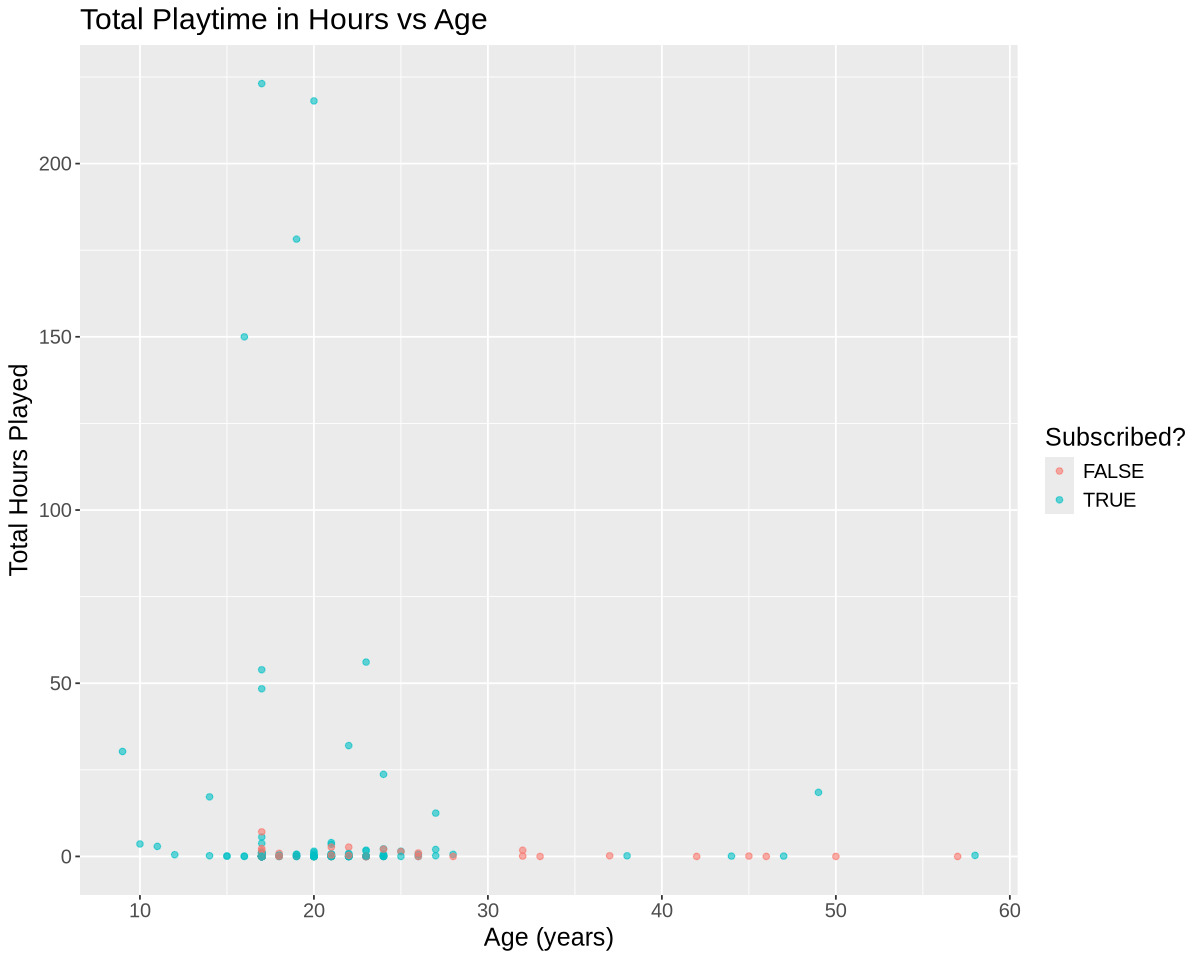

In [5]:
options(repr.plot.width = 10, repr.plot.height = 8)
age_play_time_plot <- players_tidy |>
            ggplot(aes(x = Age, y = played_hours, color = subscribe)) +
            geom_point(alpha = 0.6) +
            labs(x = "Age (years)",
                 y = "Total Hours Played",
                 color = "Subscribed?",
                 title = "Total Playtime in Hours vs Age")+
            theme(text = element_text(size = 15))
age_play_time_plot


*`Figure 2.0`, Relationship between total playtime and age, differentiated by subscription status*

This scatterplot shows the relationship of total in-game playtime (in hours) vs player age, with different colours indicating whether a player is subscribed to the newsletter. From the plot, we can see that most players under 30 years old have low total playtime. However, there are a few younger players who show higher playtime values. There is no strong relationship between age and total playtime as points are scattered, but younger players are more likely to spend a longer time playing the game. People who played for long hours (more than 25 hours) are all subscribed to the newsletter, which indicates that the total number of hours played can be useful in predicting whether a player is subscribed to the newsletter. Also, it seems like older players are less likely to subscribe to the newsletter; however, this might be because they play for fewer hours in total.


#### Bar plot: Proportion of Subscription Across Experience Levels

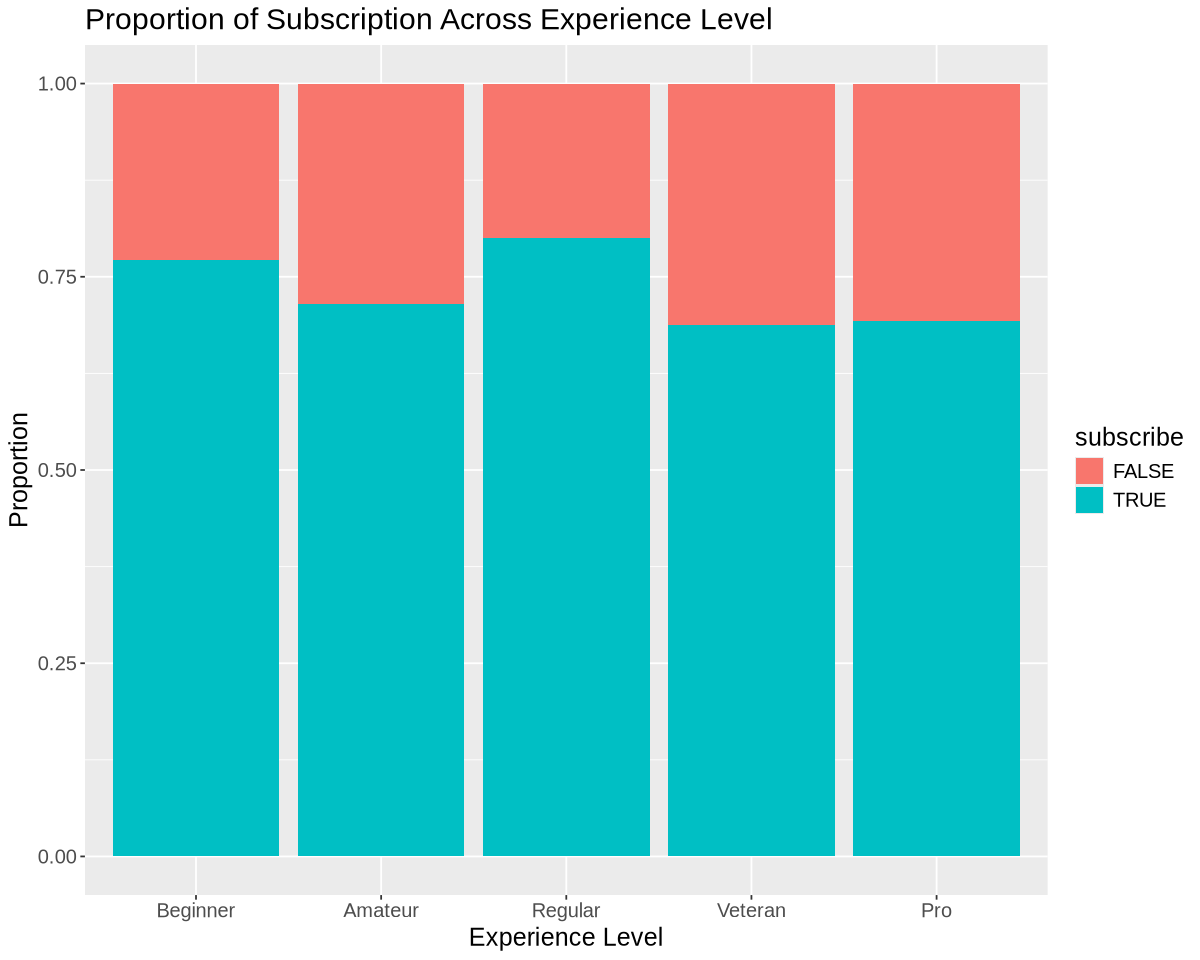

In [6]:
options(repr.plot.width = 10, repr.plot.height = 8)
                    
experience_play_time_plot <- players_tidy |>
                    ggplot(aes(x = experience, fill = subscribe)) +
                    geom_bar(position = 'fill') +
                    labs(x = "Experience Level",
                         y = "Proportion",
                         title = "Proportion of Subscription Across Experience Level") +
                    theme(text = element_text(size = 15))
experience_play_time_plot

*`Figure 2.1`, Proportion of players who are subscribed based on their experience level*

This bar plot shows the subscription status for players across different experience levels. Players who report themselves as regular or beginner tend to have a higher proportion of subscriptions (over 75%) than amateurs, veterans, and pros. This shows that although there is an overall high subscription rate (all over 50%), there are certain experience levels who are more or less likely to subscribe to the newsletter. These results indicate that experience level is a useful variable for predicting data contribution, but perhaps not as strong as the other contributors.

### Methods for Analysis

We will use **KNN classification** to predict `subscribe` from player characteristics including `Age`, `experience`, and `played_hours`.

This method is appropriate because the response variable is categorical, and KNN classification helps identify which player characteristics are most related to higher engagement with the newsletter.

KNN classification makes no assumptions about the underlying distribution.

A limitation is that KNN classification is heavily impacted by noisy data and outliers due to imbalanced datasets. This means that extreme values can negatively impact the predictive results when using this model because of its dependence on distance and proximity calculations.

Before using our classification model, categorical variables such as `experience` will be converted into numerical form so they can be used in KNN models. The data will be split into 75% training and 25% testing sets. No separate validation set will be used because we are using cross-validation. Models will be checked using accuracy, and 5-fold cross-validation will be used to ensure consistent performance. The final model will be chosen based on the $K$ that gives the highest accuracy, which shows the most accurate predictions. 

### Convert `experience` into numerical form

In [7]:
players_tidy <- players_tidy |>
                    mutate(experience = as.numeric(experience))

### Split the Data into Training and Testing Datasets

In [8]:
library(tidymodels)

── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filter()   masks stats::filter()
✖ recipes::fixed()  masks stringr::fixed()
✖ dplyr::lag()      masks stats::lag()
✖ yardstick::spec() masks readr::spec()
✖ recipes::step()   masks stats::step()
• Learn how to get started at https://www.tidymodels.org/start/



In [9]:
set.seed(4321)
players_split <- initial_split(players_tidy, prop = .75, strata = subscribe)
players_training <- training(players_split)
players_testing <- testing(players_split)

### Perform cross-validation to choose k

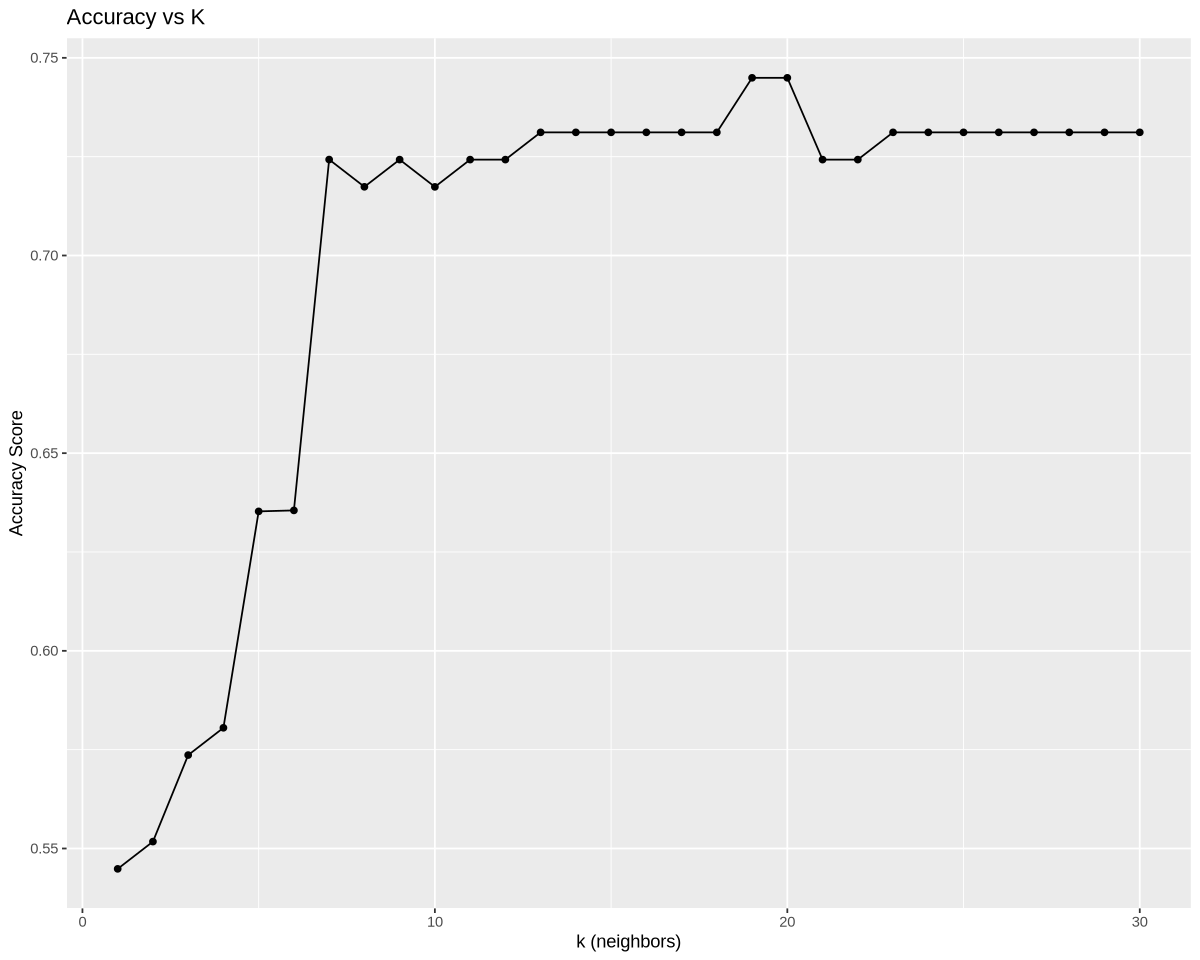

In [10]:
set.seed(999)
players_recipe <- recipe(subscribe ~ ., data = players_training) |>
                    step_center(all_predictors()) |>
                    step_scale(all_predictors())

players_folds <- vfold_cv(players_training, v = 5, strata = subscribe)

knn_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
                set_engine("kknn") |>
                set_mode("classification")

k_vals <- tibble(neighbors = seq(from = 1, to = 30, by = 1))

players_fit <- workflow() |>
                add_recipe(players_recipe) |>
                add_model(knn_tune) |>
                tune_grid(resamples = players_folds, grid = k_vals) |>
                collect_metrics()

accuracies <- players_fit |>
                filter(.metric == "accuracy")|>
                select(neighbors, .metric, mean)

cross_val_plot <- ggplot(accuracies, aes(x = neighbors, y = mean) ) +
                    geom_point () +
                    geom_line() +
                    labs (x = "k (neighbors)", y = "Accuracy Score", title = "Accuracy vs K")

cross_val_plot

*`Figure 2.2`, Relationship Between K (neighbors) and accuracy, to determine the best K.*

### Build the Final Model & Evaluate

In [11]:
players_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 20) |>
                set_engine("kknn") |>
                set_mode("classification")

players_fit_best <- workflow() |>
                    add_recipe(players_recipe) |>
                    add_model(players_spec) |>
                    fit(players_training)

players_predictions <- predict(players_fit_best, players_testing) |>
                        bind_cols(players_testing)

players_metrics <- players_predictions |>
                     metrics(truth = subscribe, estimate = .pred_class) |>
                     filter(.metric == "accuracy")
players_metrics

players_conf_mat <- players_predictions |>
     conf_mat(truth = subscribe, estimate = .pred_class)
players_conf_mat

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7346939


          Truth
Prediction FALSE TRUE
     FALSE     0    0
     TRUE     13   36

*`Figure 1.5`, Prediction Matrix of the KNN model.*

## 3. Discussion

Our exploratory analysis suggests that certain player characteristics, particularly age, total hours played, and experience level are valuable in determining whether a player subscribes to the server’s newsletter. We found that none of the player characteristics were useful in predicting the subscription status than the other variables. Nevertheless, we still built our model using all 3 predictive variables, considering the small size of our dataset. 

We trained a k-nearest neighbors (k-NN) classification model and applied cross-validation to determine the optimal number of neighbors. The tuning results indicated that model performance peaked at $K = 20$. Using our model with optimal $K$ we were able to predict the subscription status of our testing data with $73.47$% of accuracy. This accuracy reflects the proportion of players whose subscription status the model correctly predicted. Measurements of accuracy do not tell the full story when it comes to our model's performance, but they give a general idea if we are in the right direction to answer our question. However, the confusion matrix (`Figure 1.5`) showed that our model predicted 100% of the players to be subscribed, possibly due to the high percentage of subscribed players in the dataset (imbalanced) and the small size of the data. 

Overall, our model achieved unsatisfactory predictive performance after comparing our results to a basic model that predicts the majority class all the time. This suggests that while player behavior and demographics contain some signal related to newsletter subscription, they do not fully determine it. More observations might be necessary to strengthen predictions.

These findings could help server moderators and community managers who are trying to increase engagement with their newsletter after gathering more observations and building a stronger model. Age being a strong factor in predicting subscription status, tailoring advertisements or incentives according to the prominent age in the server could increase community involvement with the newsletter. Additionally, understanding player behaviour can influence how they apply targeted communication and make better decisions about future events. 

Our work raises several potential questions for future investigation:

- What other factors influence the likelihood of subscribing to the newsletter?
- Could more complex models increase accuracy?
- Does player behaviour change after subscribing?

Overall, our findings open a door to richer exploration on how player engagement with a community newsletter could increase when we can find patterns in their behaviour. 

## References 
- Pacific Laboratory for Artificial Intelligence (PLAI). (2024). PLAICRAFT Players Data Set (F. Wood, Lead Researcher). Retrieved from: https://plaicraft.ai
- Pacific Laboratory for Artificial Intelligence (PLAI). (2024). PLAICRAFT Sessions Data Set (F. Wood, Lead Researcher). Retrieved from: https://plaicraft.ai
- Pacific Laboratory for Artificial Intelligence (PLAI). (2024). PLAICRAFT Formal Invitation (F. Wood, Lead Researcher). Retrieved from: https://www.youtube.com/watch?v=PdIjQAhQ3Xk&t=79s
- GameSpot. (2025). Top 10 Best Selling Games of All Time (Eddie Makuch, Author). Retrieved from: https://www.gamespot.com/gallery/top-10-best-selling-video-games-of-all-time/2900-4814/#1